# Insurance Fraud Data — Preprocessing Pipeline

## 1. Imports

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler

## 2. Load Data

In [2]:
df = pd.read_csv("insurance_fraud_data.csv")
df.rename(columns={
    "policy deductible": "policy_deductible",
    "annual premium": "annual_premium",
    "days open": "days_open",
    "form defects": "form_defects",
    "fraud reported": "fraud_reported"
}, inplace=True)
df.shape

(12002, 29)

## 3. Clean Missing Values
`*` is used as a placeholder for missing data across several columns, so it is unified to `NaN` before dropping.

In [3]:
df.replace("*", np.nan, inplace=True)
df.drop(columns=["claim_number", "zip_code"], inplace=True)

for col in ["age_of_vehicle", "injury_claim", "marital_status", "witness_present"]:
    df[col] = pd.to_numeric(df[col])

df.dropna(subset=["fraud_reported"], inplace=True)
df.dropna(inplace=True)
df.shape

(11873, 27)

## 4. Date Feature Extraction

In [4]:
df["claim_date"] = pd.to_datetime(df["claim_date"], format="%m/%d/%Y", errors="coerce")
df["claim_year"] = df["claim_date"].dt.year
df["claim_month"] = df["claim_date"].dt.month
df["claim_day"] = df["claim_date"].dt.day
df.drop(columns=["claim_date"], inplace=True)
df.dropna(inplace=True)

## 5. Outlier Removal
Each numeric column is cleaned using either the quantile cutoff or IQR method, matching the rule identified for that column's distribution.

In [5]:
Numerical_columns = df.columns[df.dtypes != "object"]
Numerical_columns

Index(['age_of_driver', 'marital_status', 'safety_rating', 'annual_income',
       'high_education', 'address_change', 'past_num_of_claims',
       'witness_present', 'liab_prct', 'police_report', 'age_of_vehicle',
       'vehicle_price', 'total_claim', 'injury_claim', 'policy_deductible',
       'annual_premium', 'days_open', 'form_defects', 'claim_year',
       'claim_month', 'claim_day'],
      dtype='object')

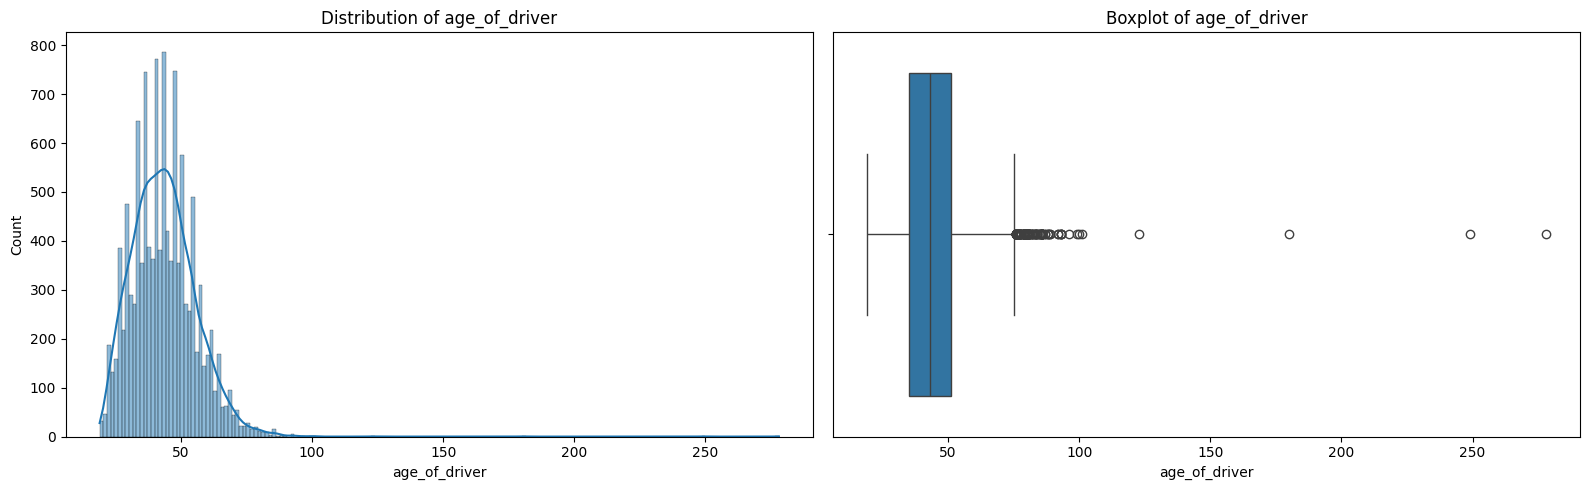

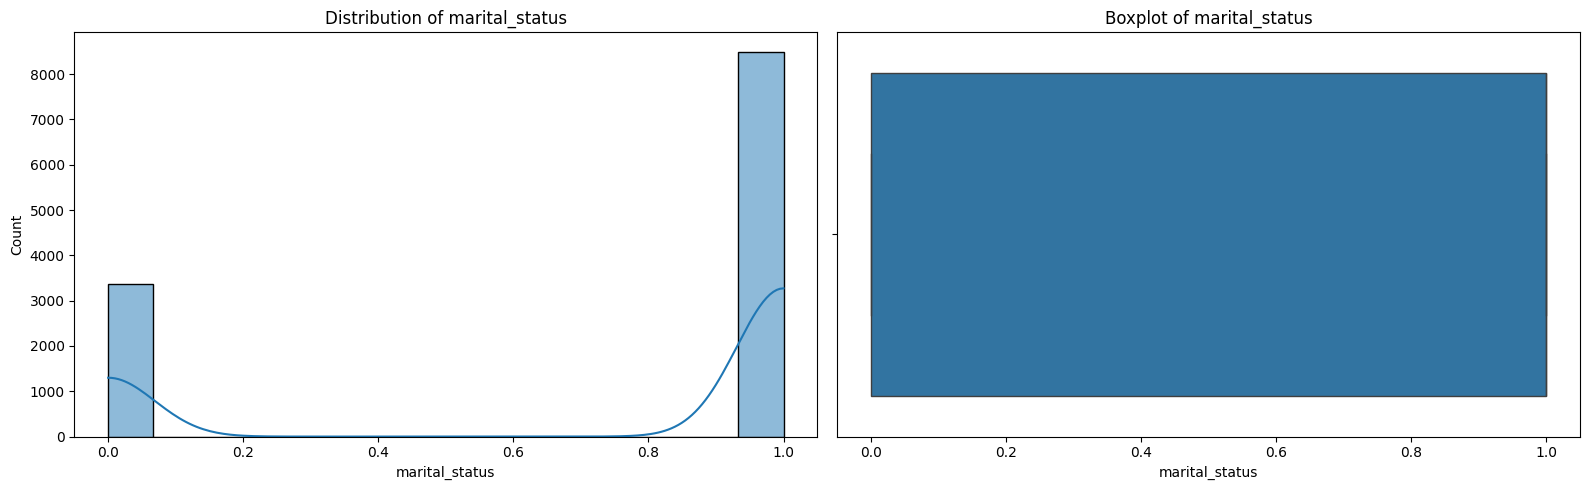

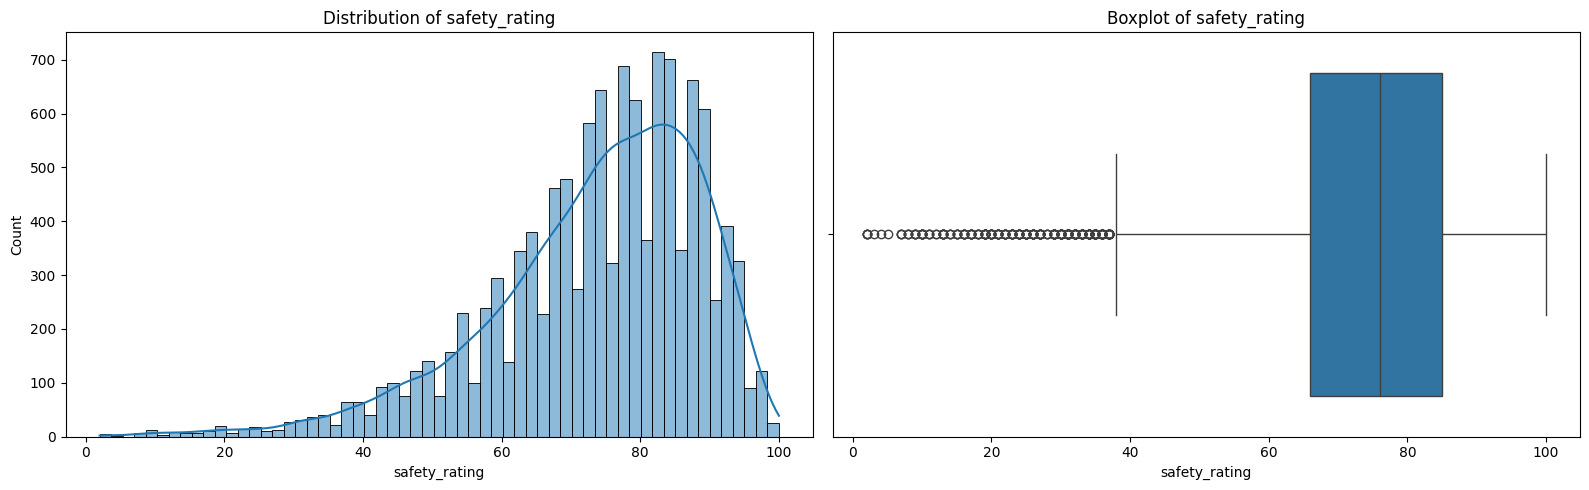

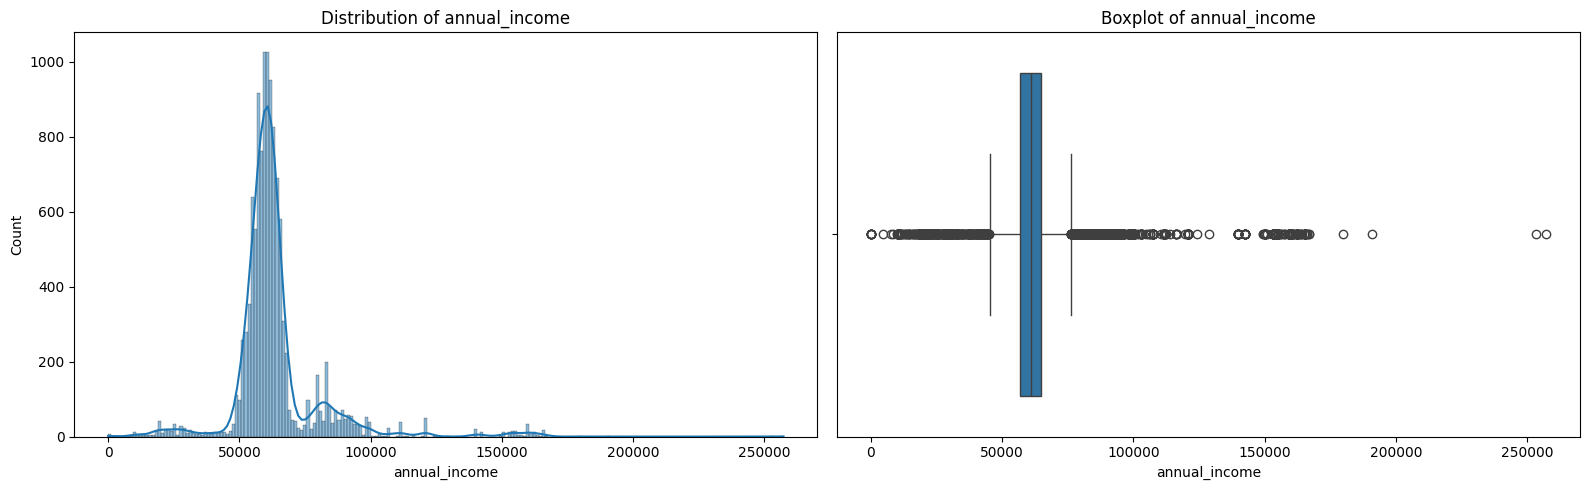

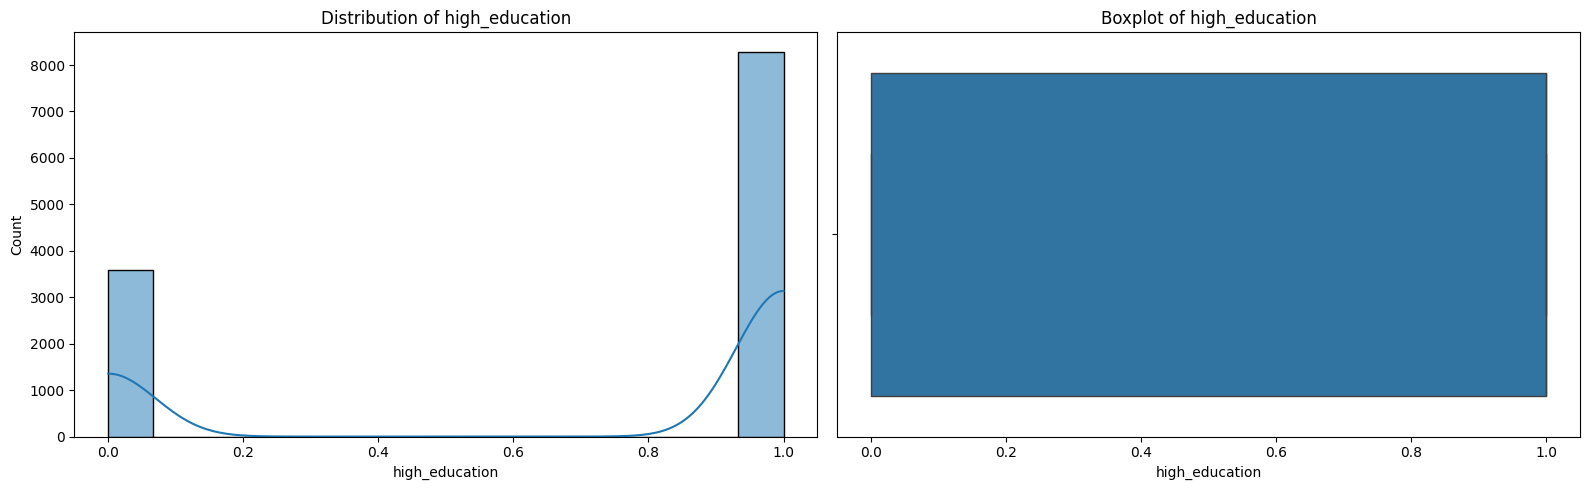

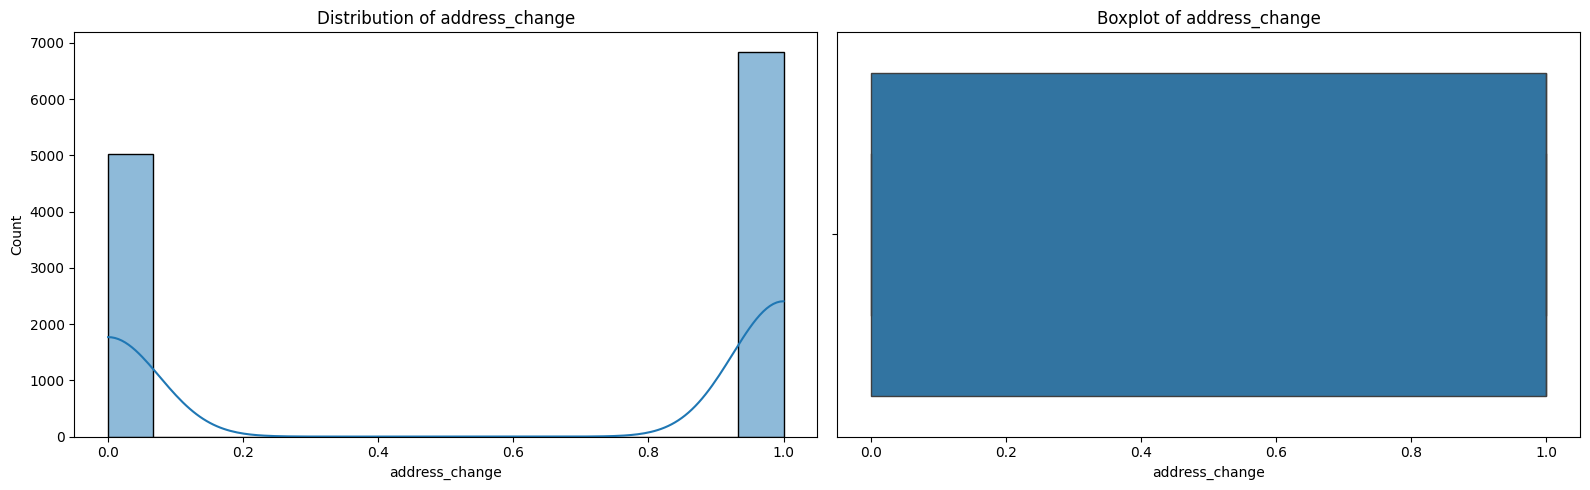

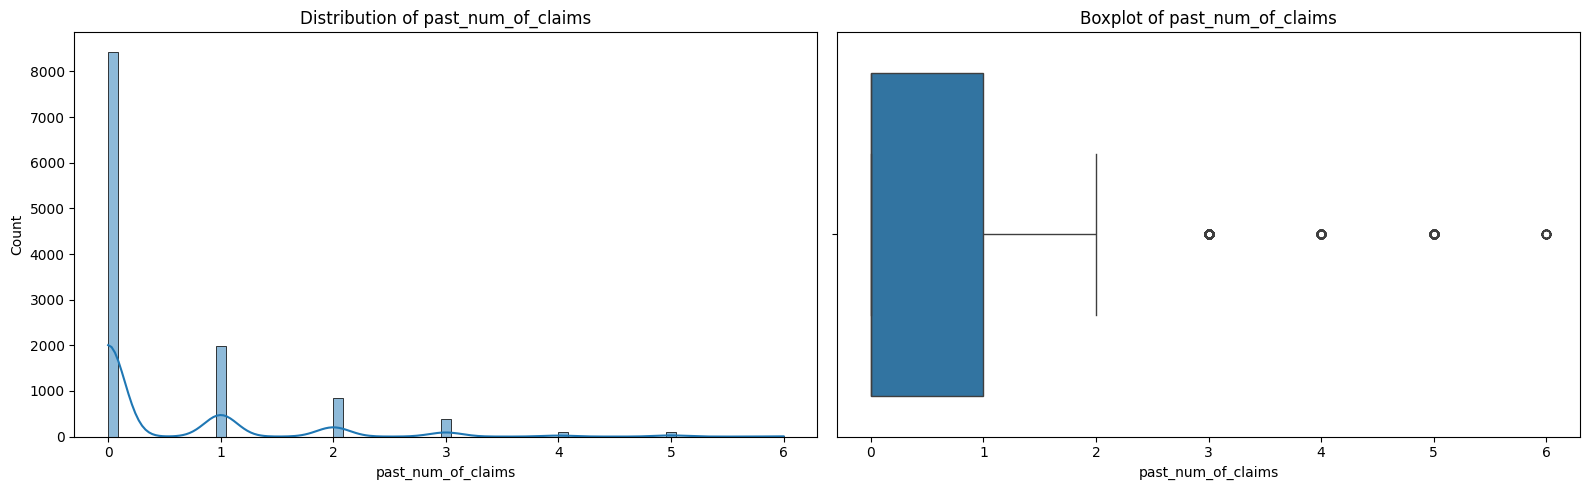

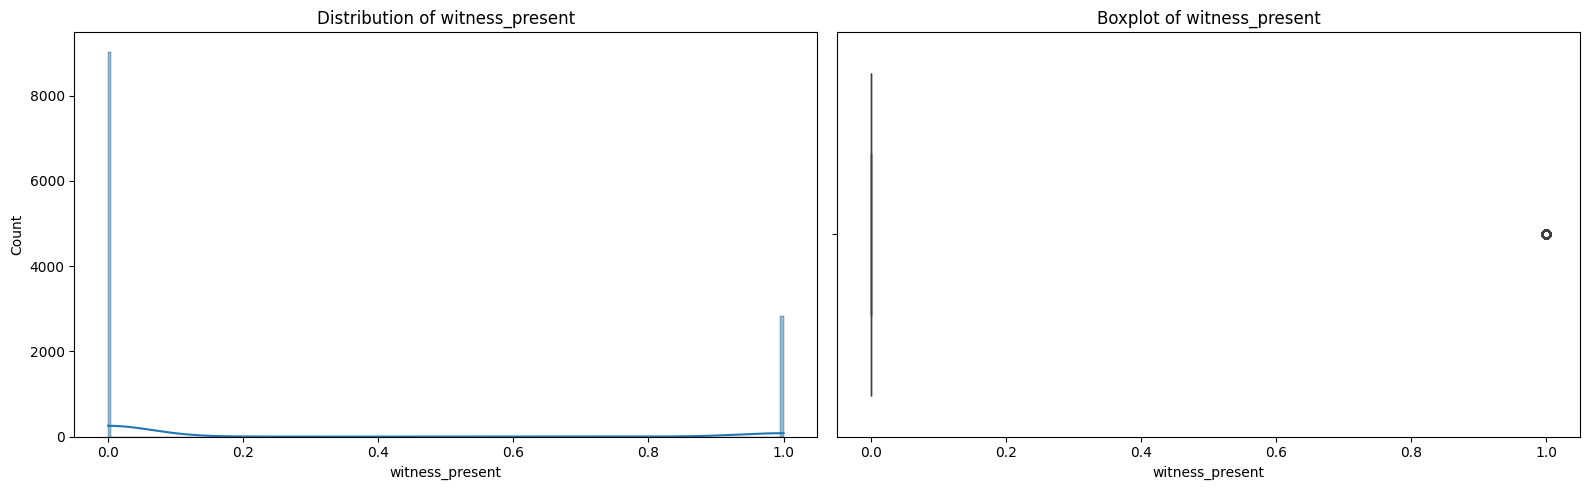

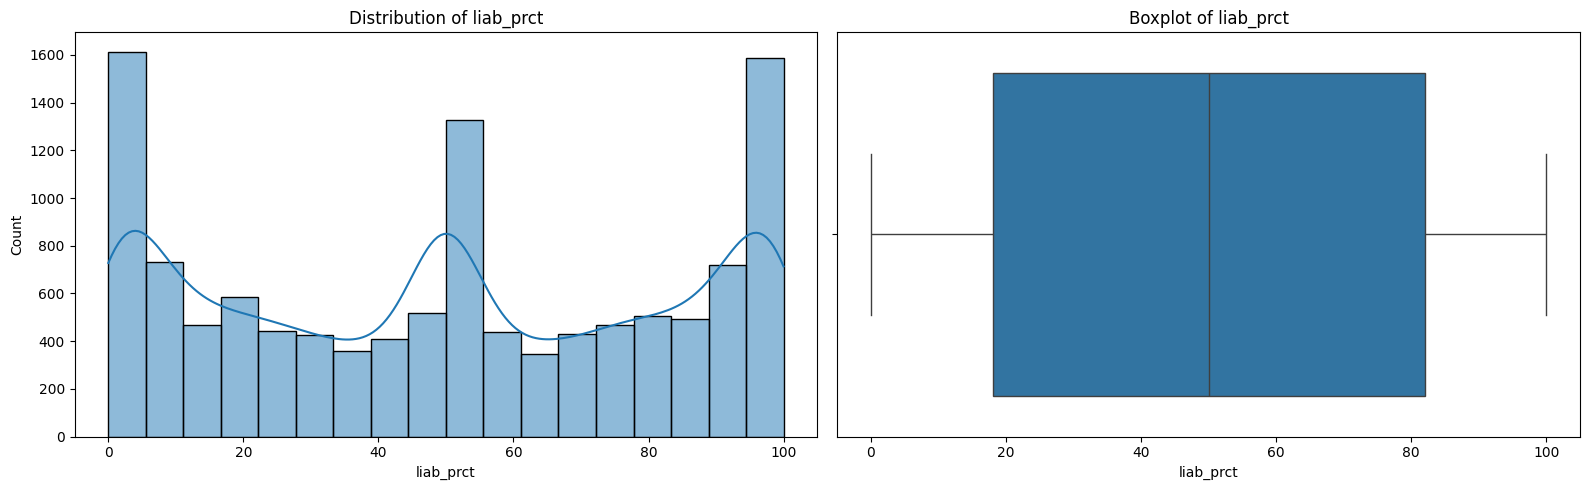

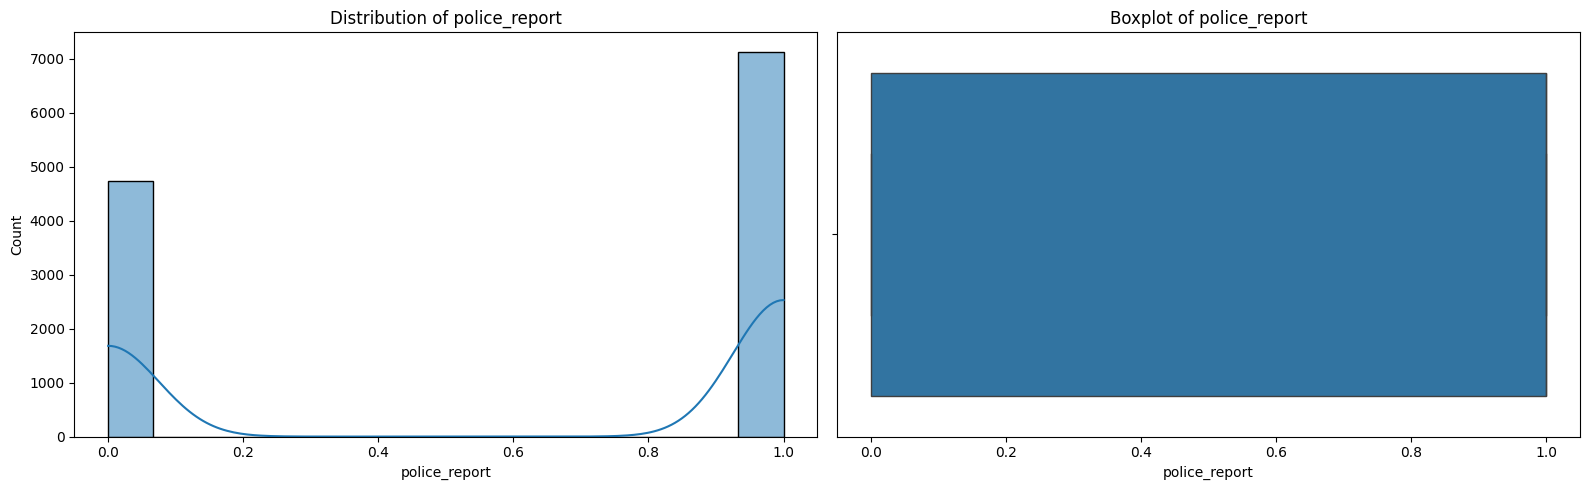

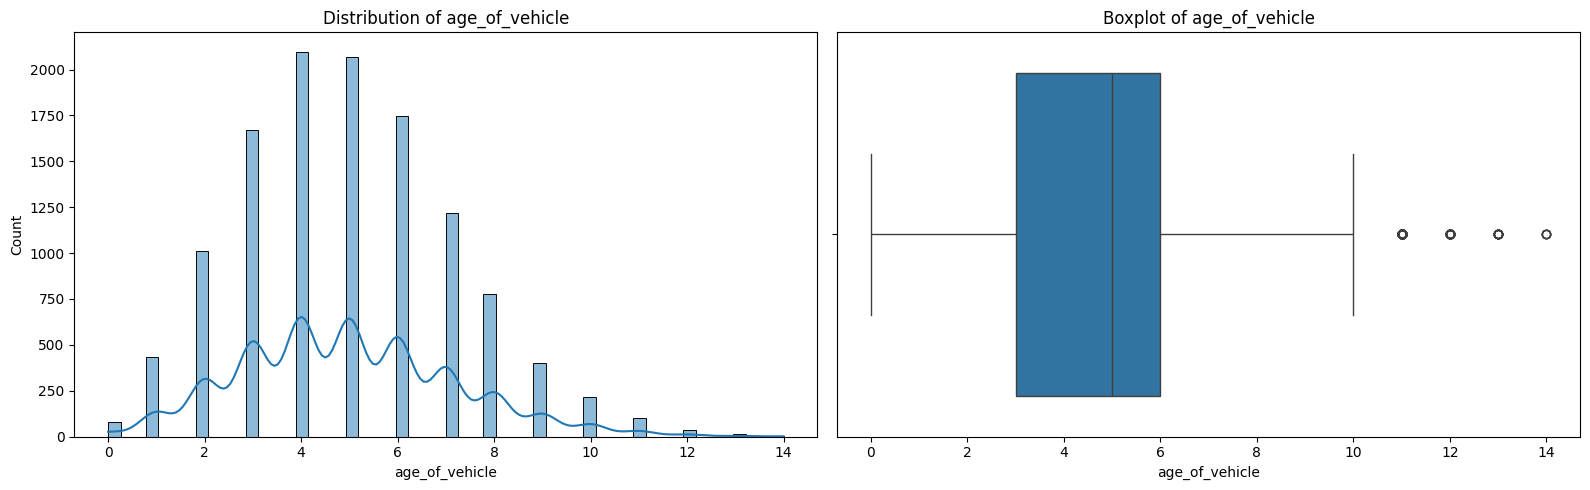

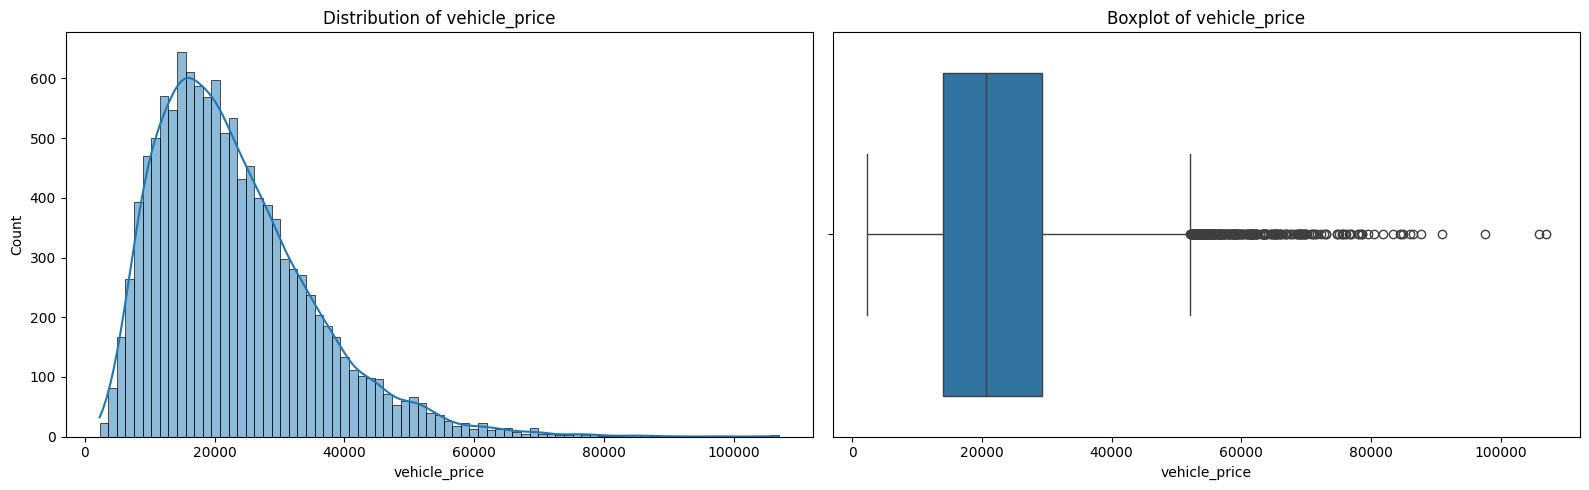

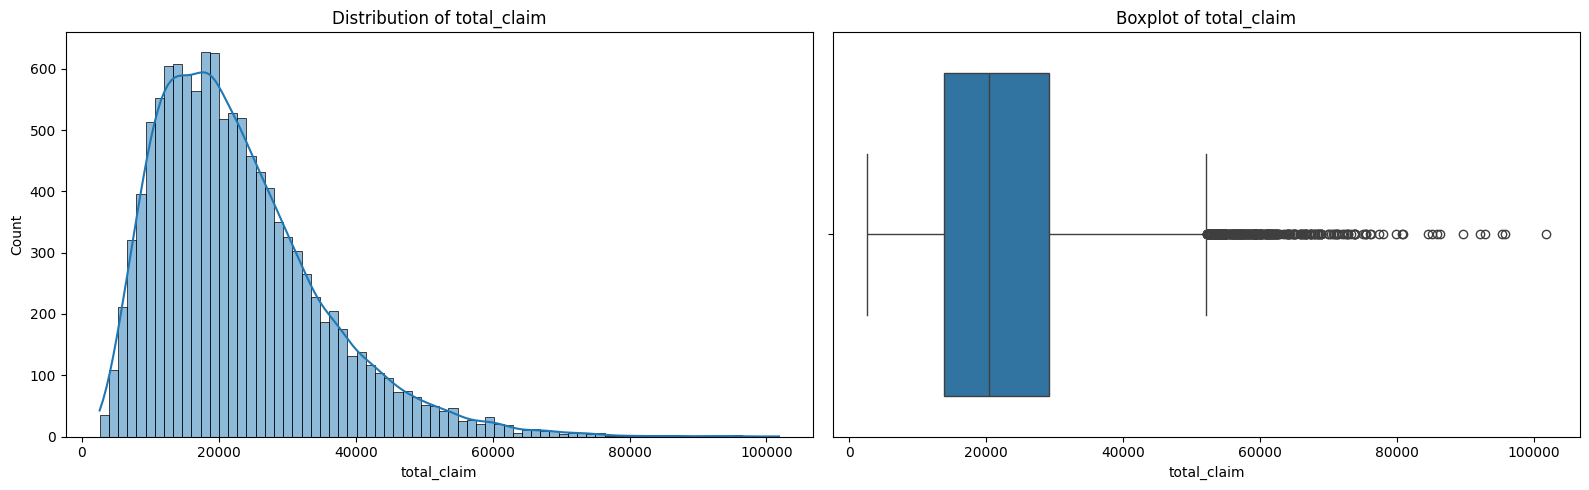

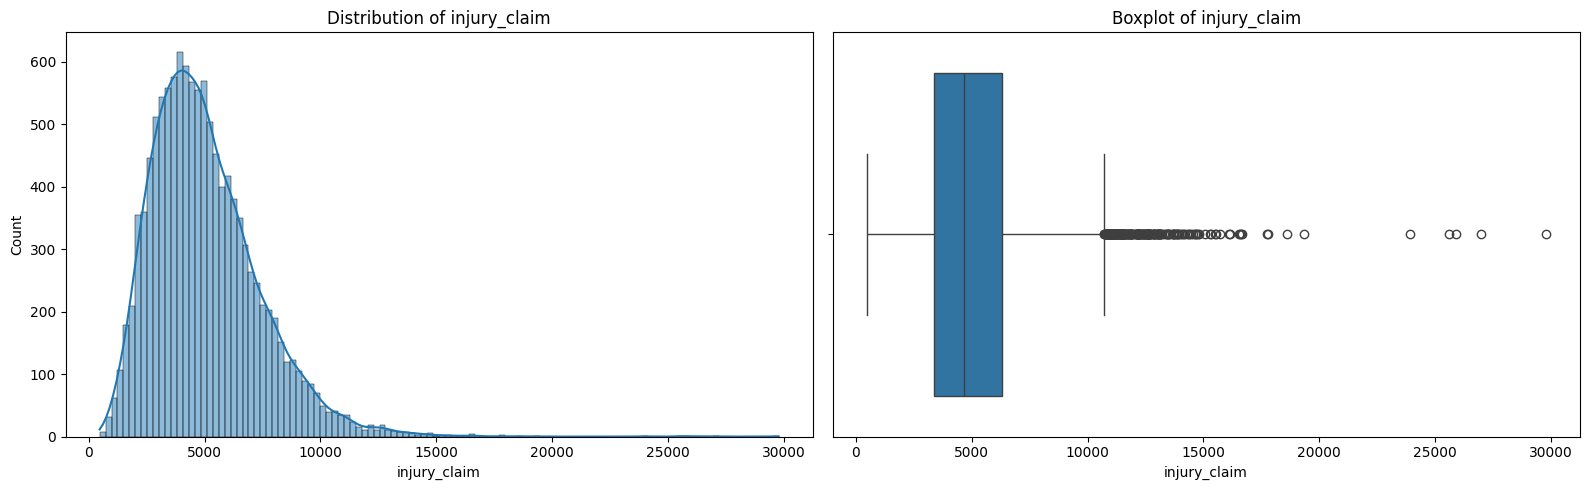

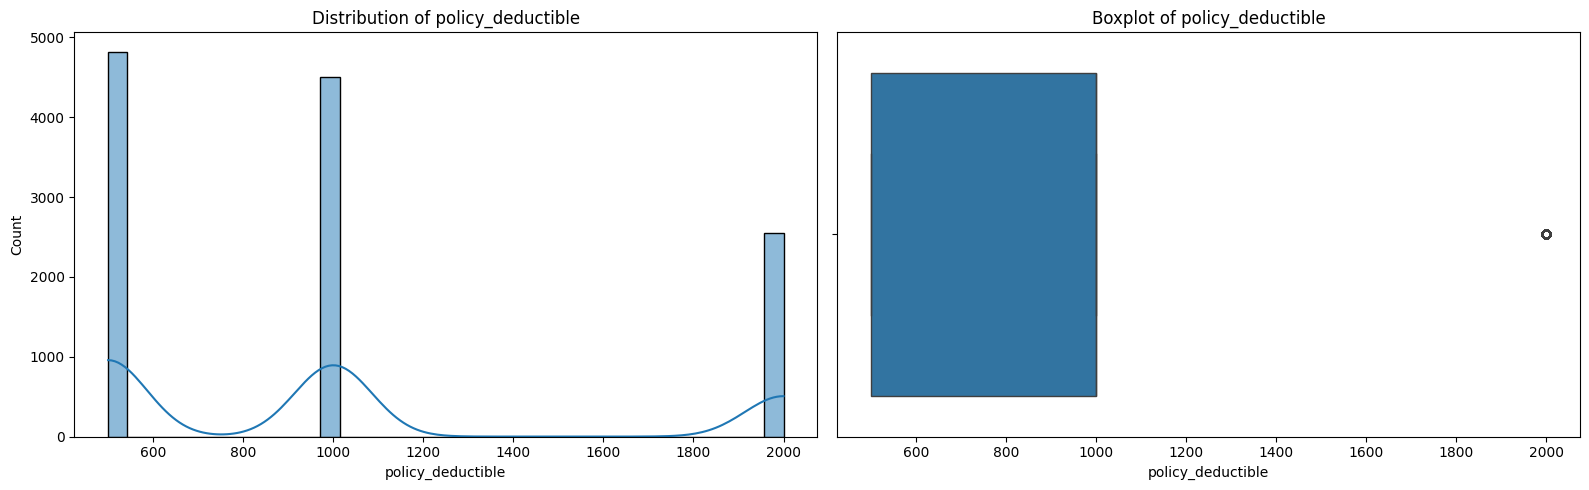

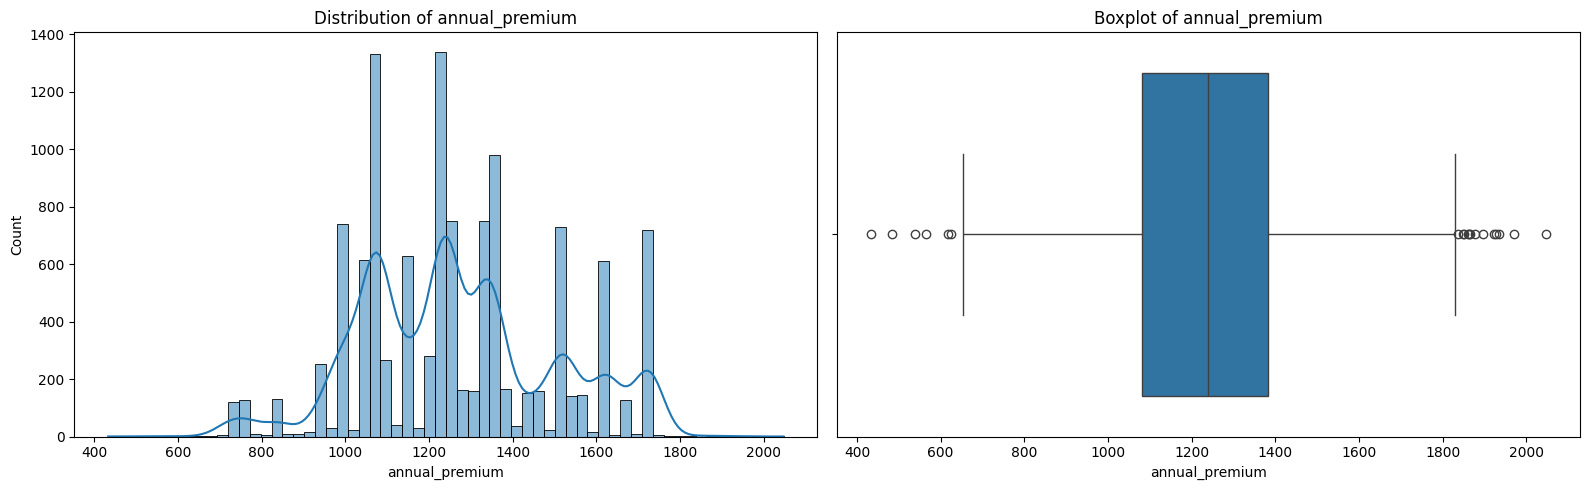

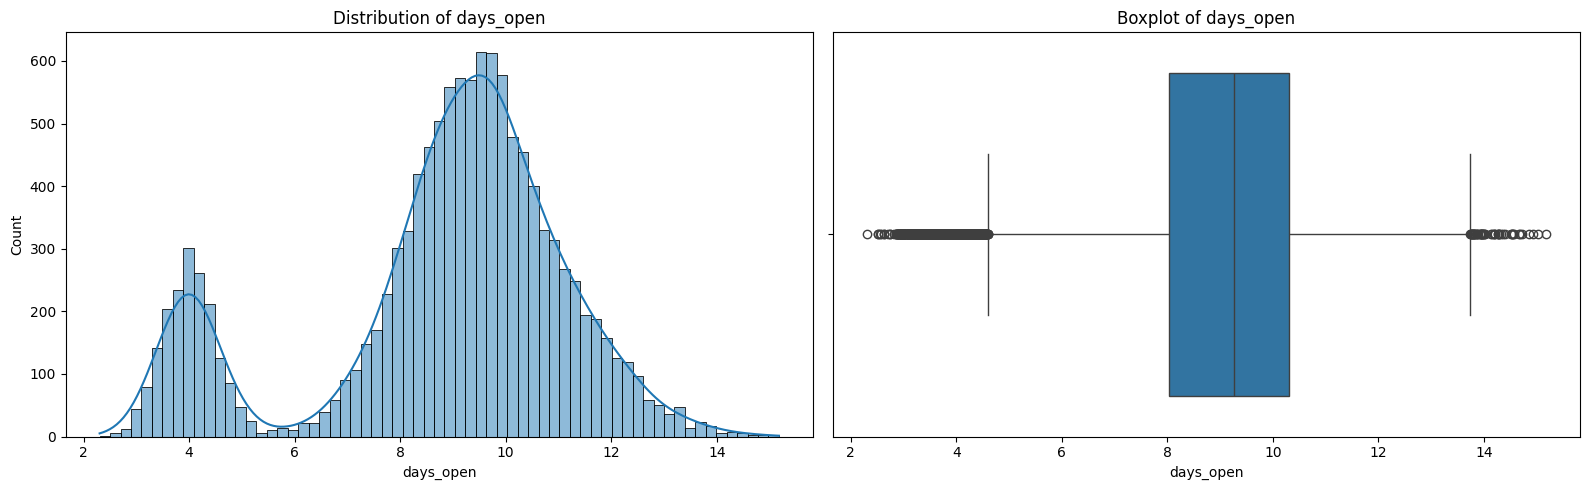

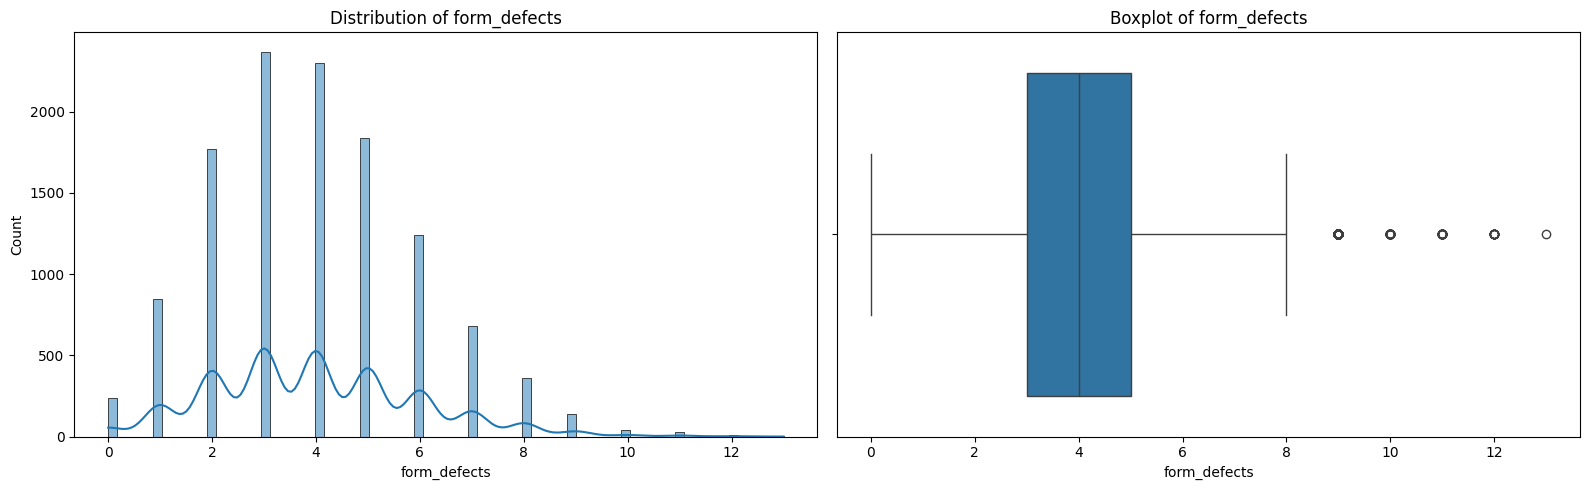

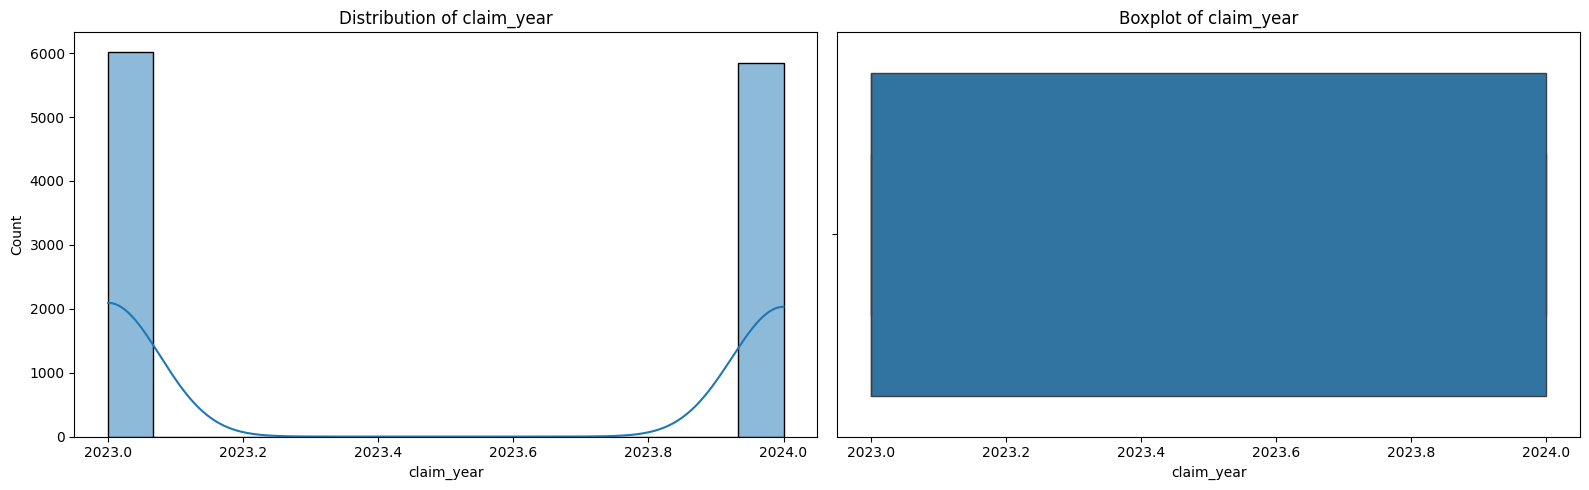

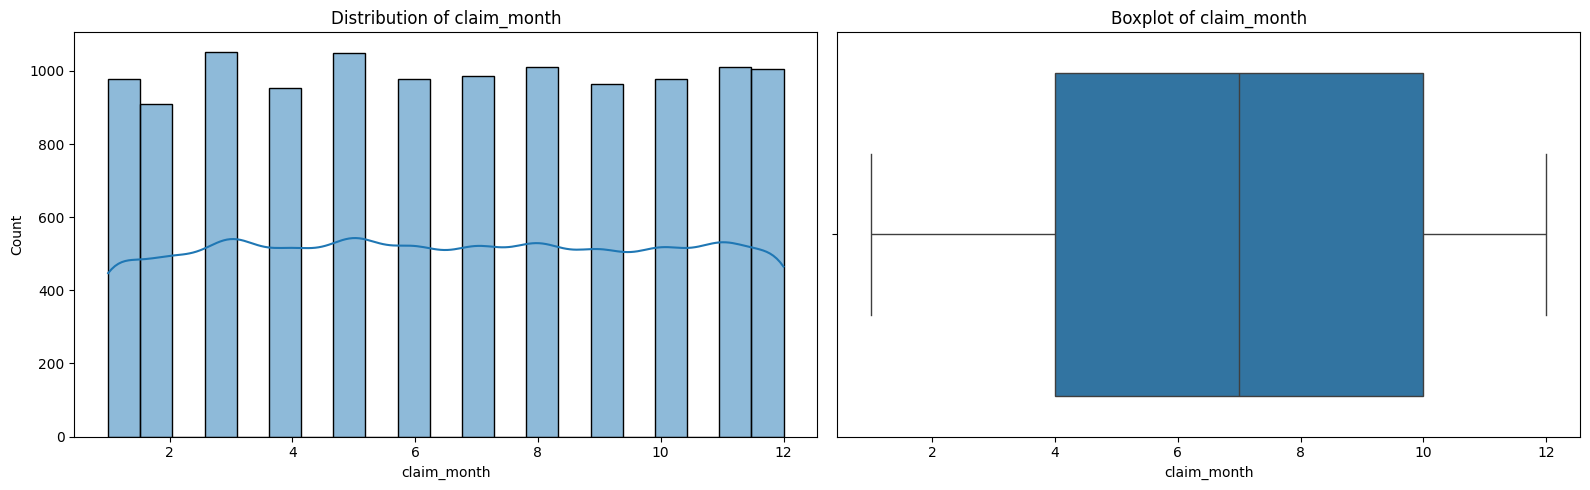

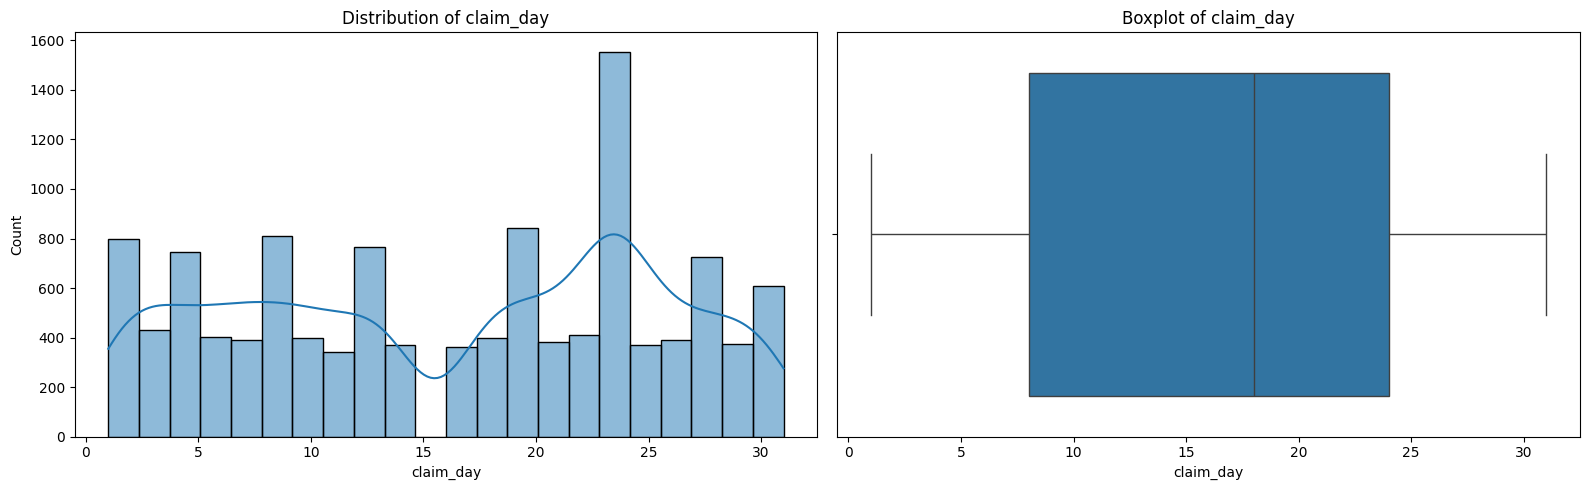

In [6]:
for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [7]:
def remove_quantile_outliers(data, col, q):
    return data[data[col] < data[col].quantile(q)]

def remove_iqr_outliers(data, col, q1=0.25, q3=0.75):
    Q1, Q3 = data[col].quantile(q1), data[col].quantile(q3)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[col] > lower) & (data[col] < upper)]

outlier_rules = {
    "age_of_driver": ("quantile", 0.99),
    "safety_rating": ("iqr", (0.25, 0.75)),
    "annual_income": ("iqr", (0.20, 0.80)),
    "vehicle_price": ("quantile", 0.97),
    "total_claim": ("quantile", 0.97),
    "annual_premium": ("iqr", (0.25, 0.75)),
    "days_open": ("iqr", (0.22, 0.78)),
}

for col, (method, param) in outlier_rules.items():
    df = remove_quantile_outliers(df, col, param) if method == "quantile" else remove_iqr_outliers(df, col, *param)

df.reset_index(drop=True, inplace=True)
df.shape

(8904, 29)

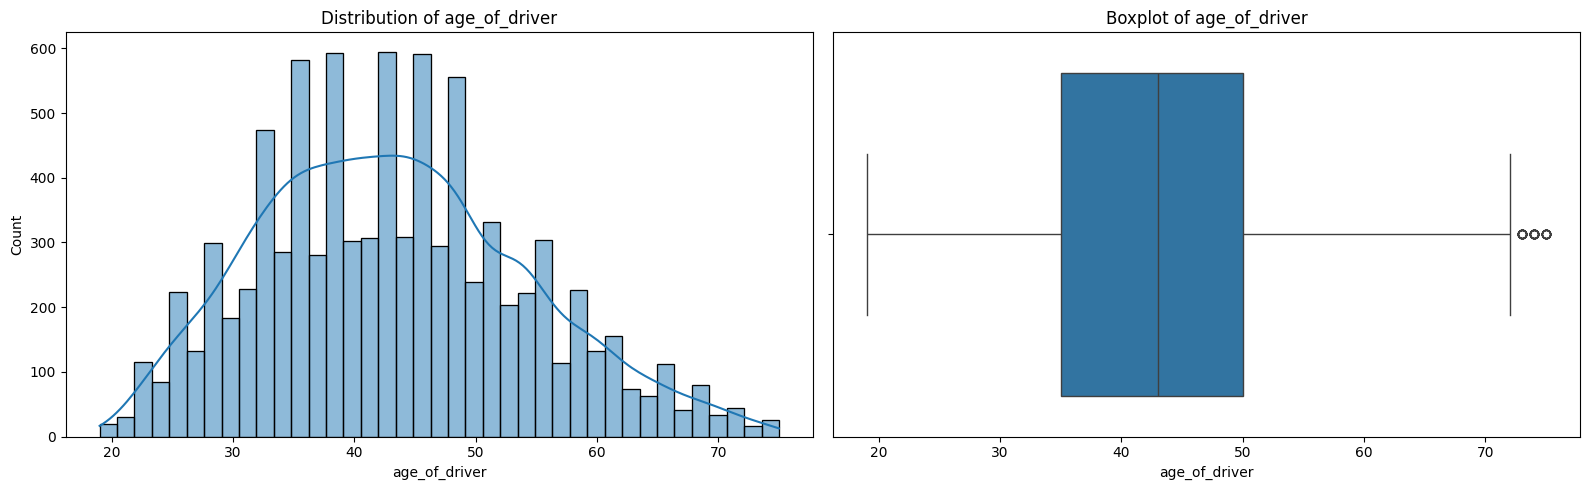

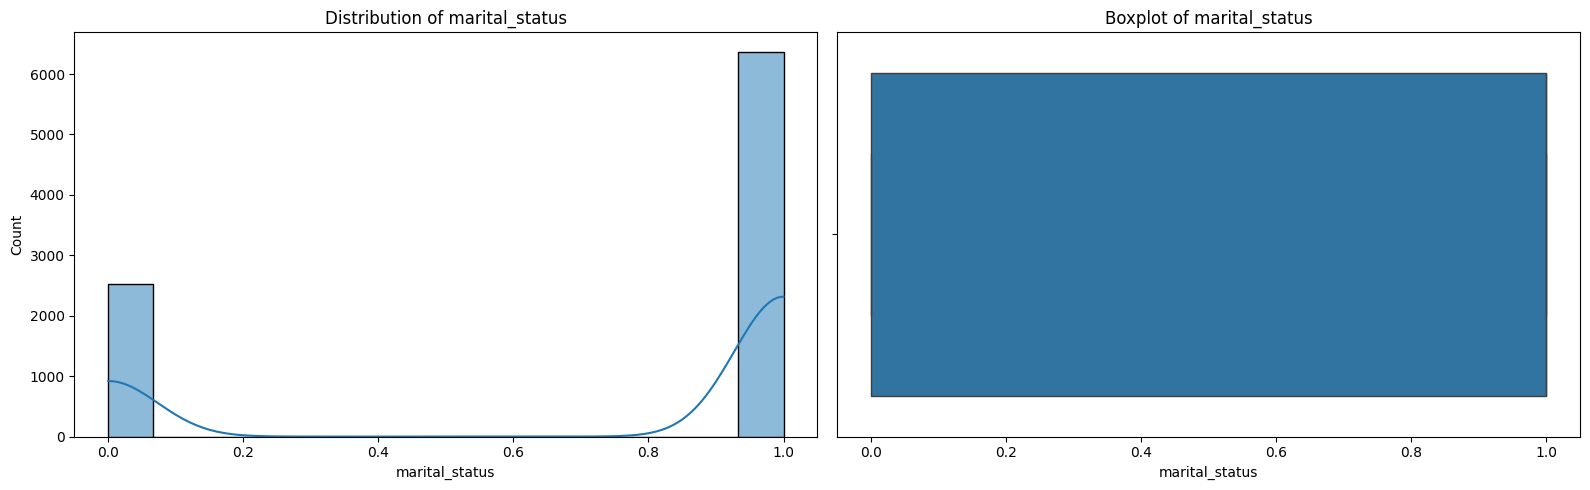

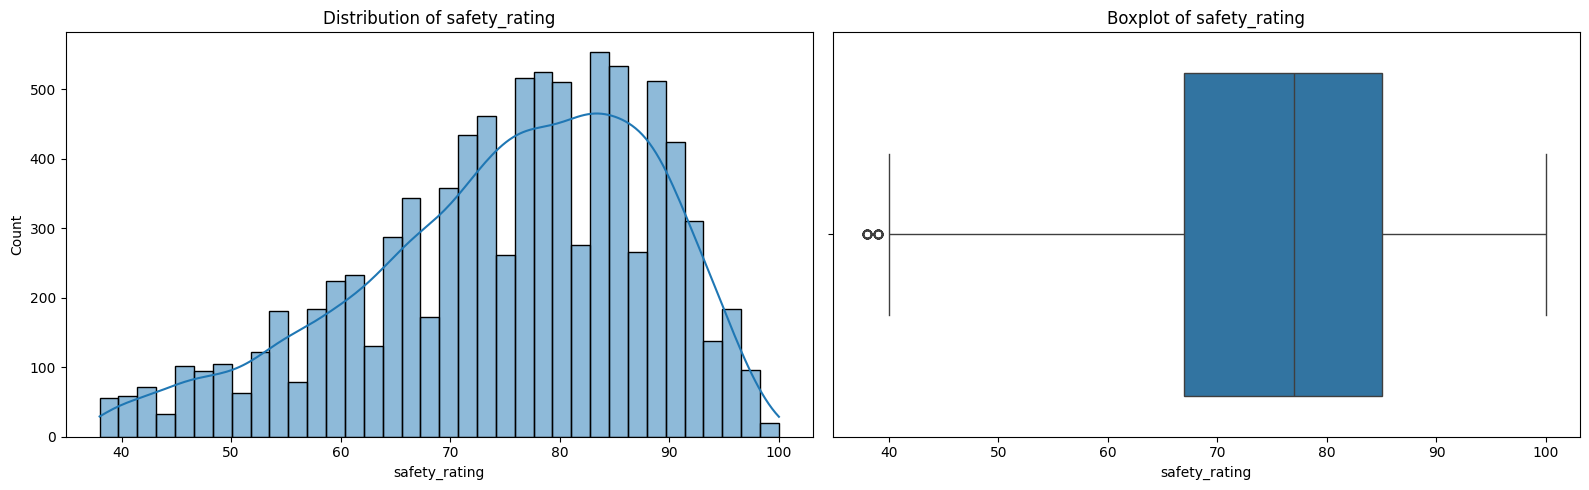

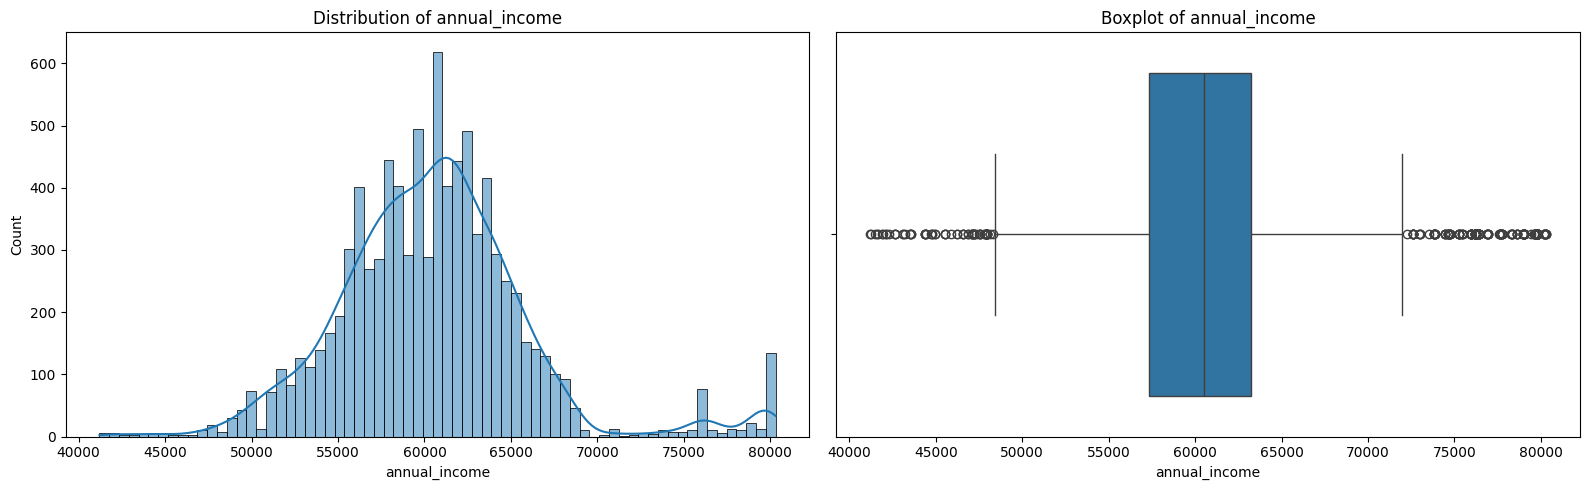

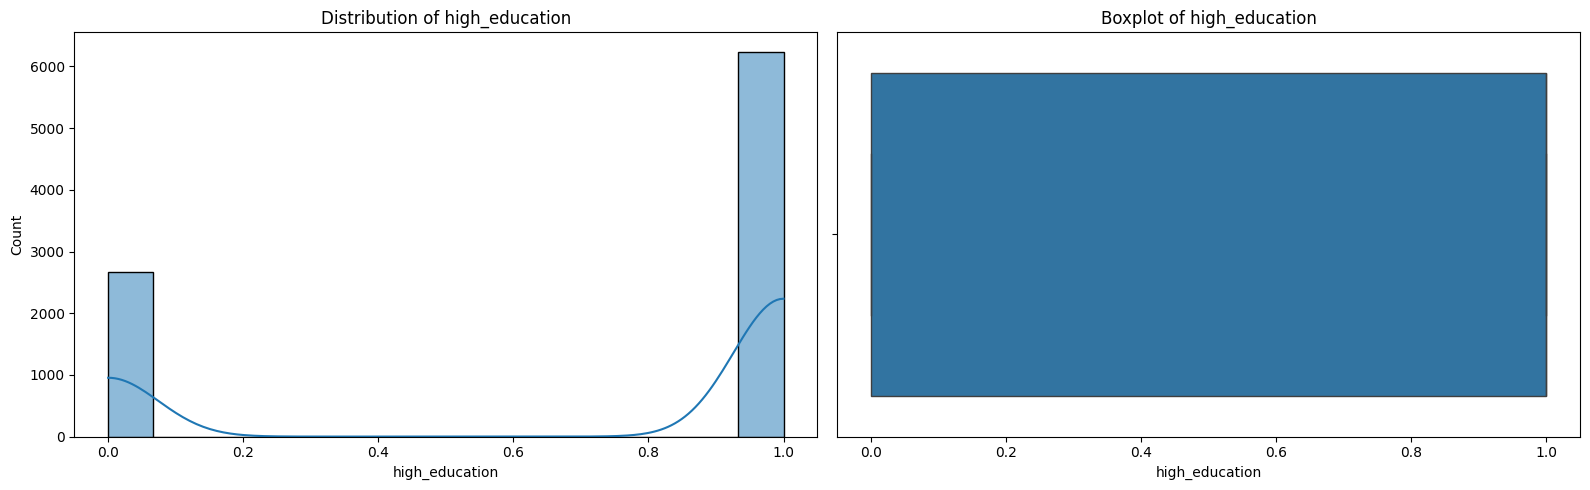

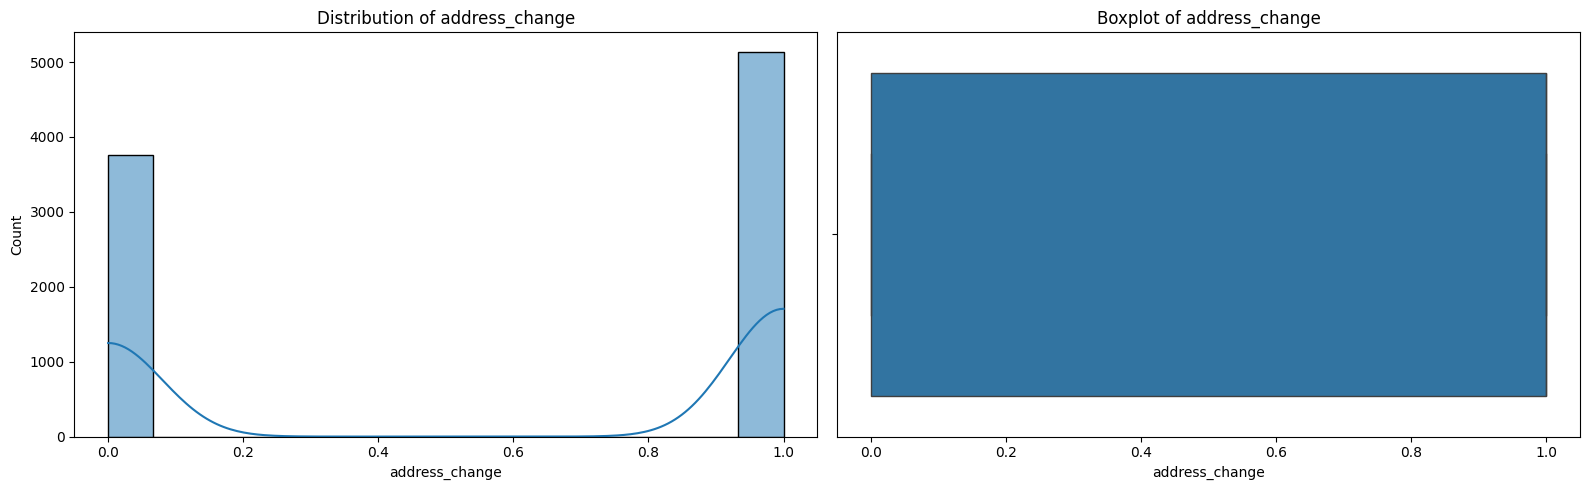

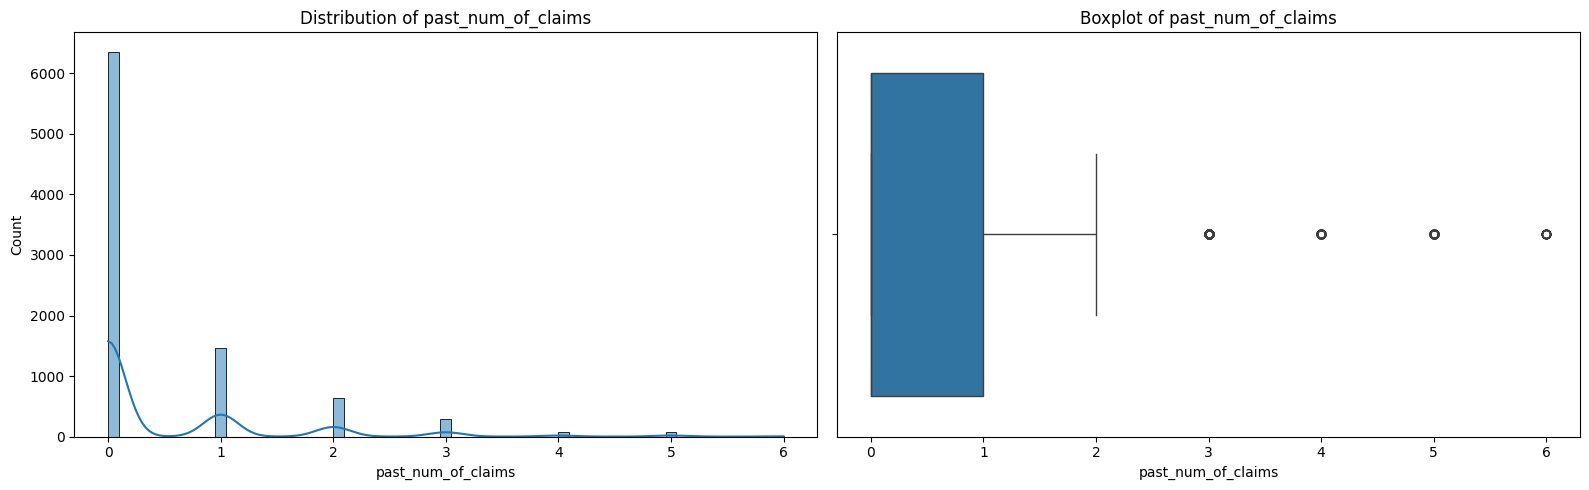

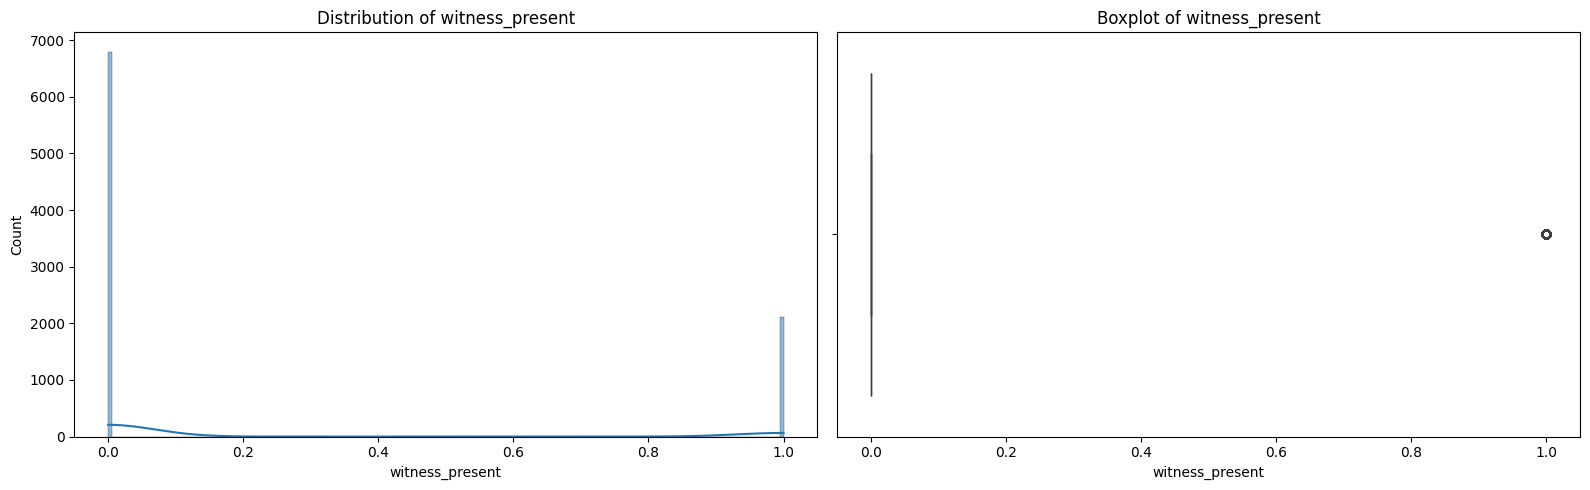

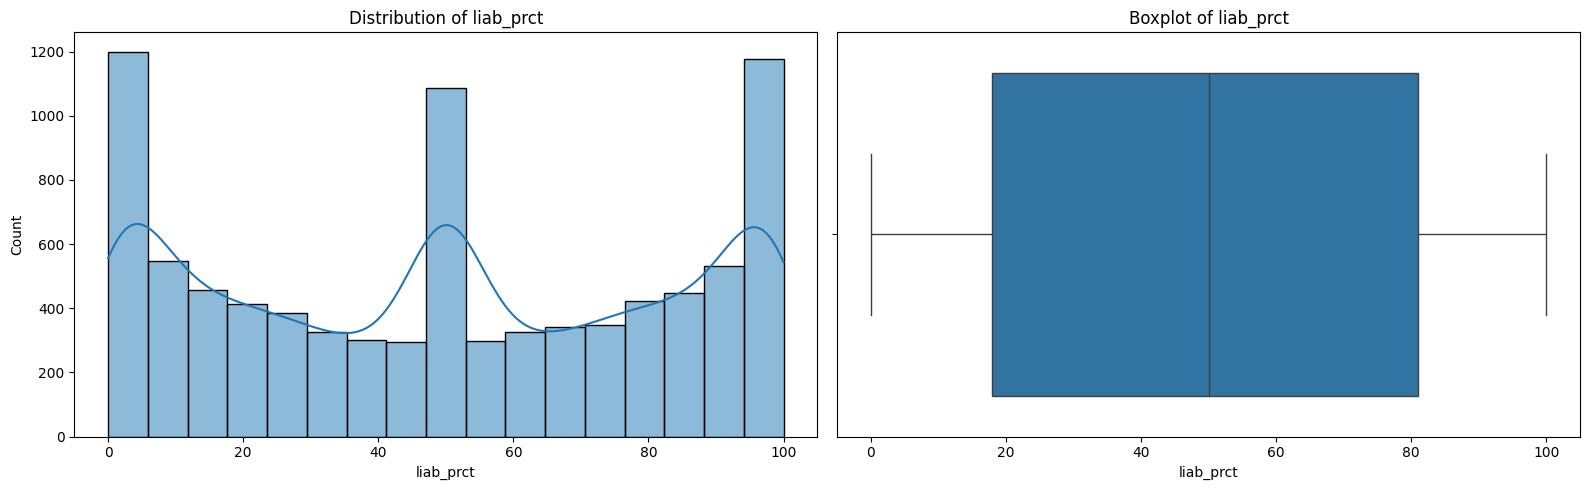

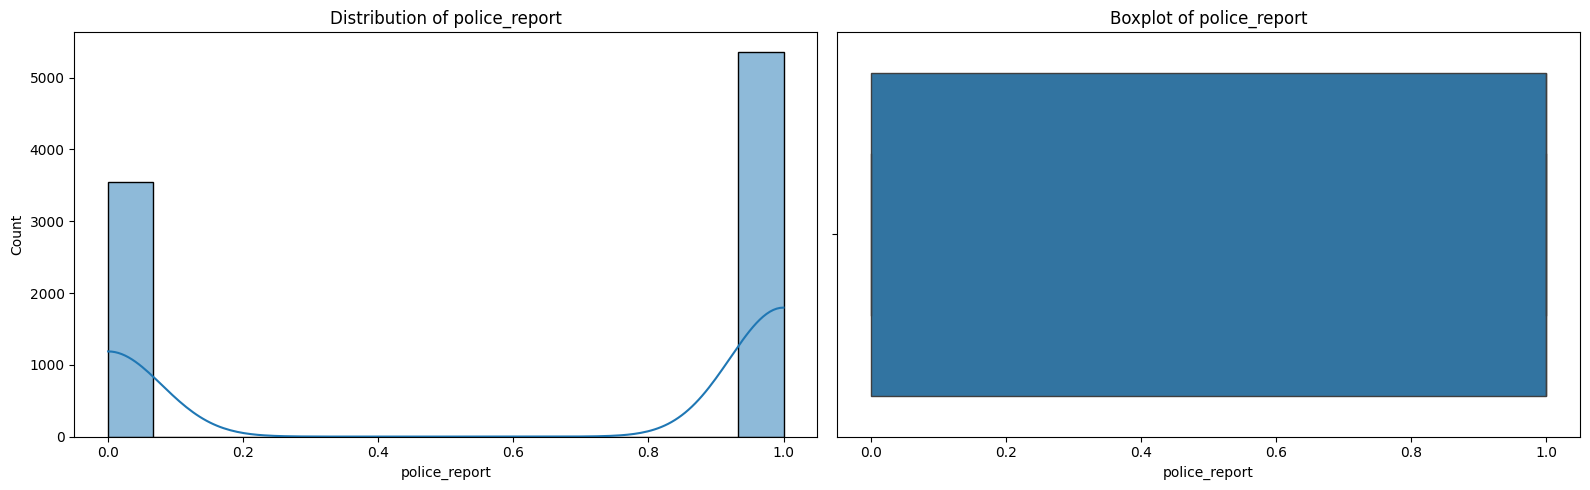

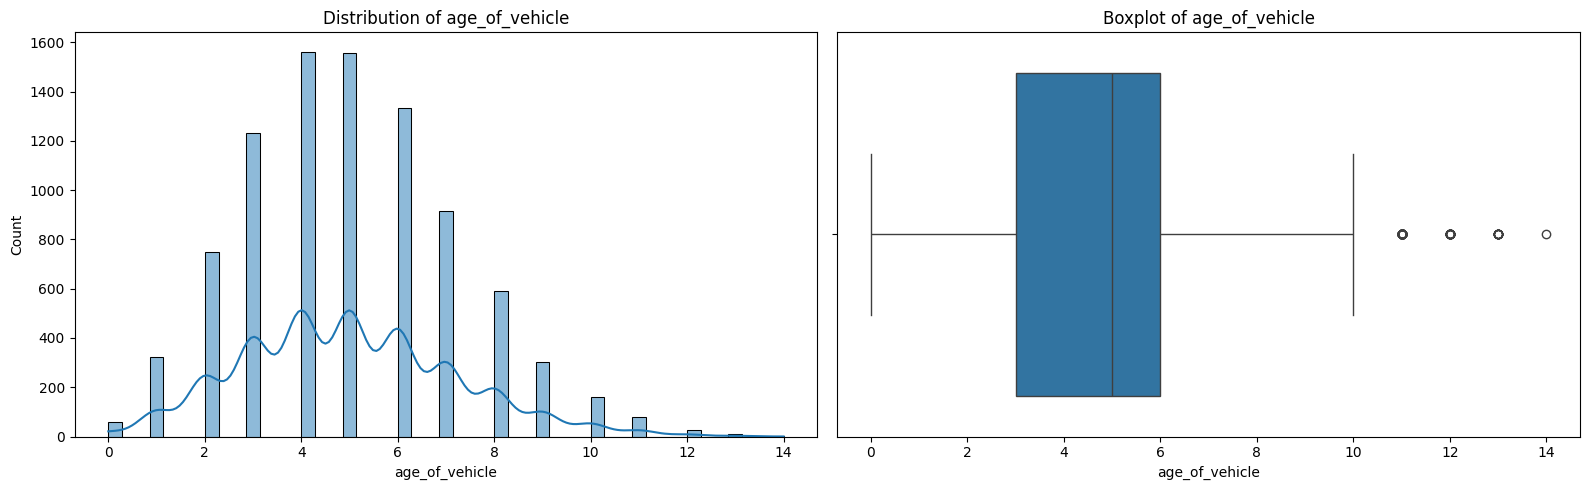

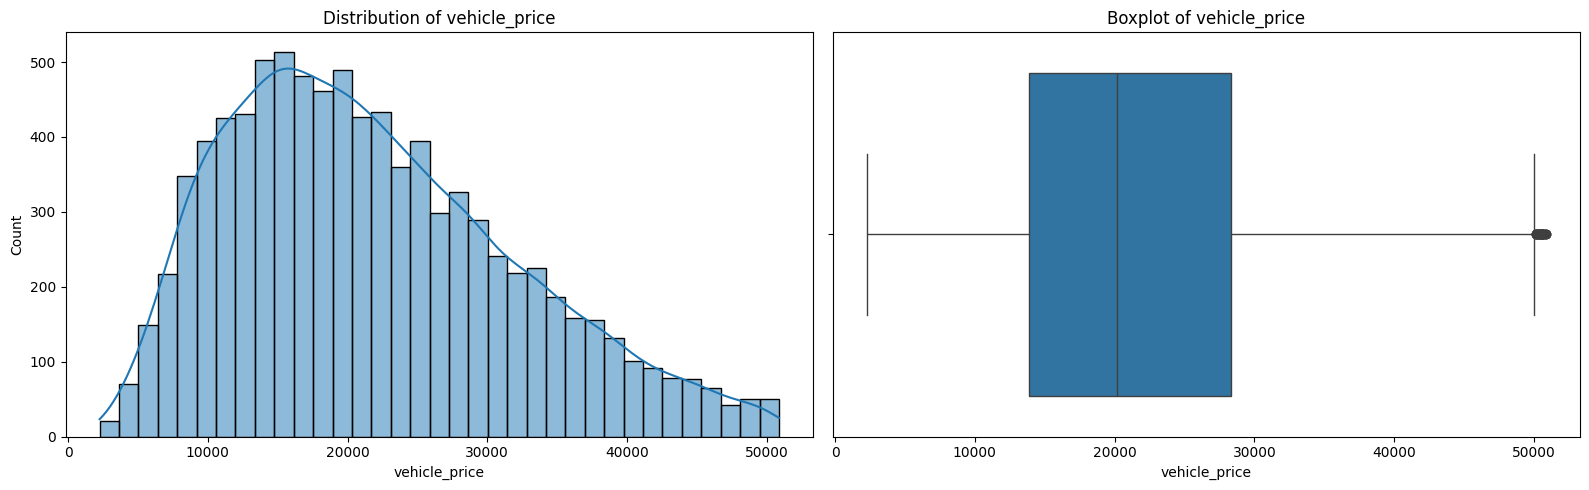

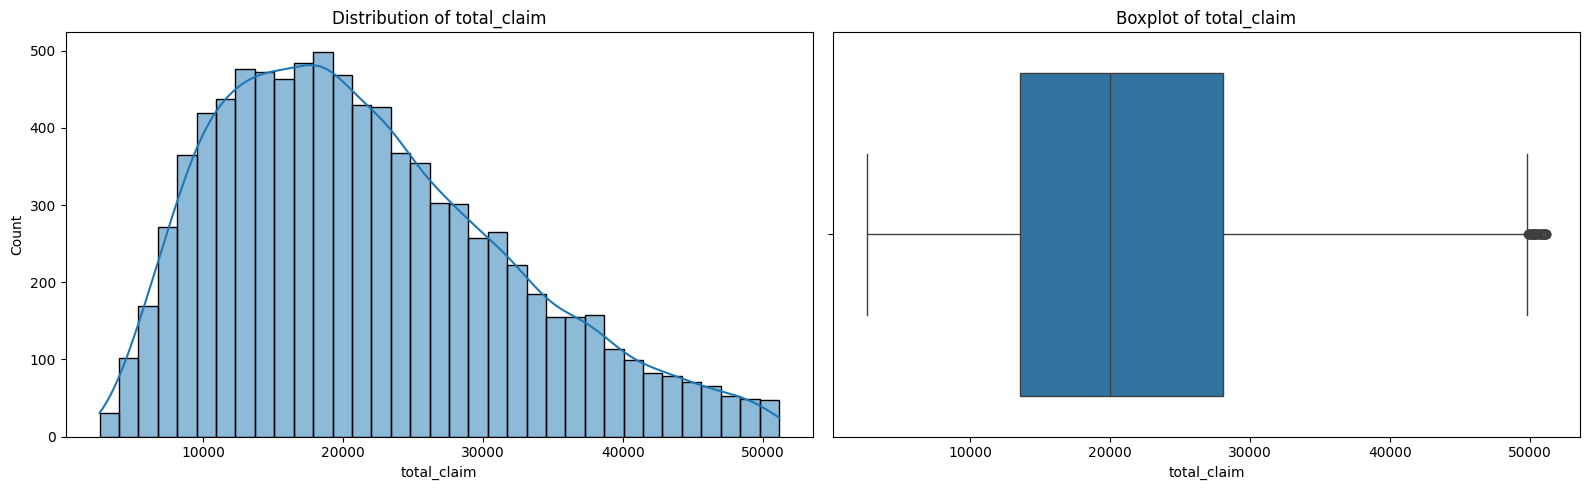

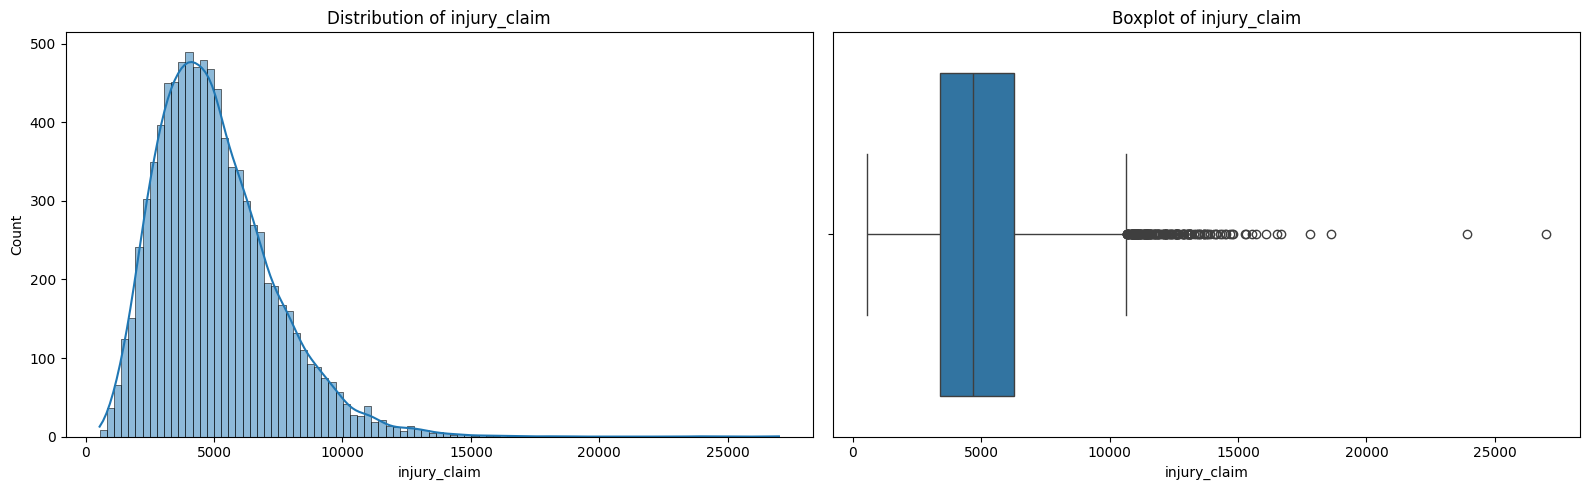

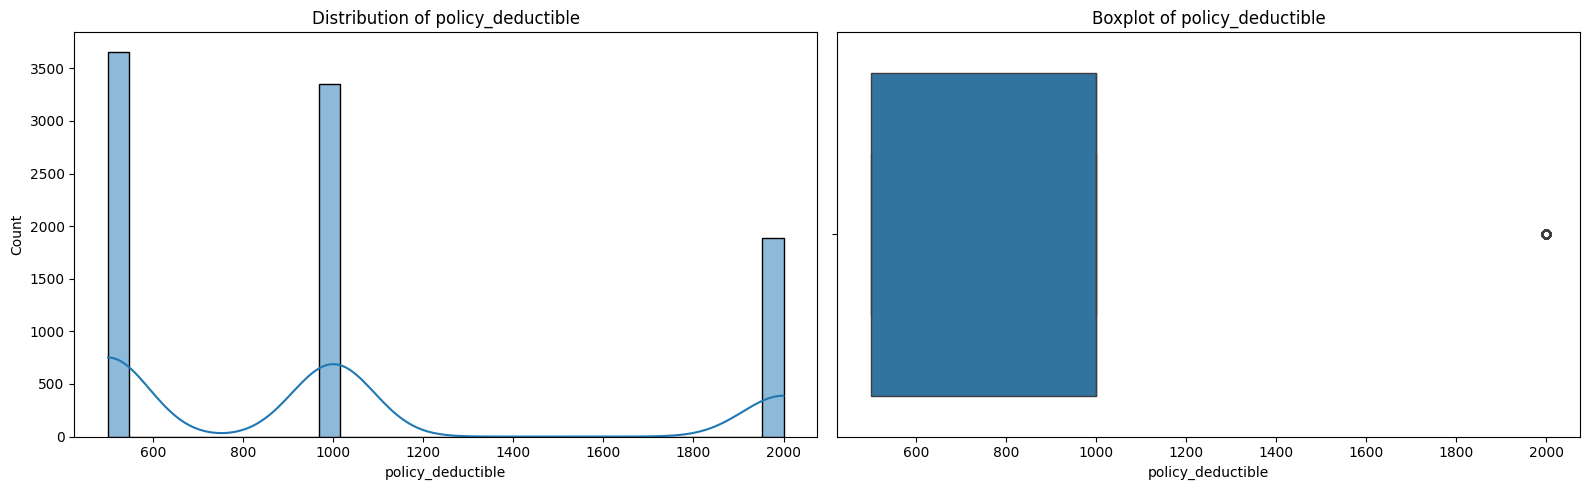

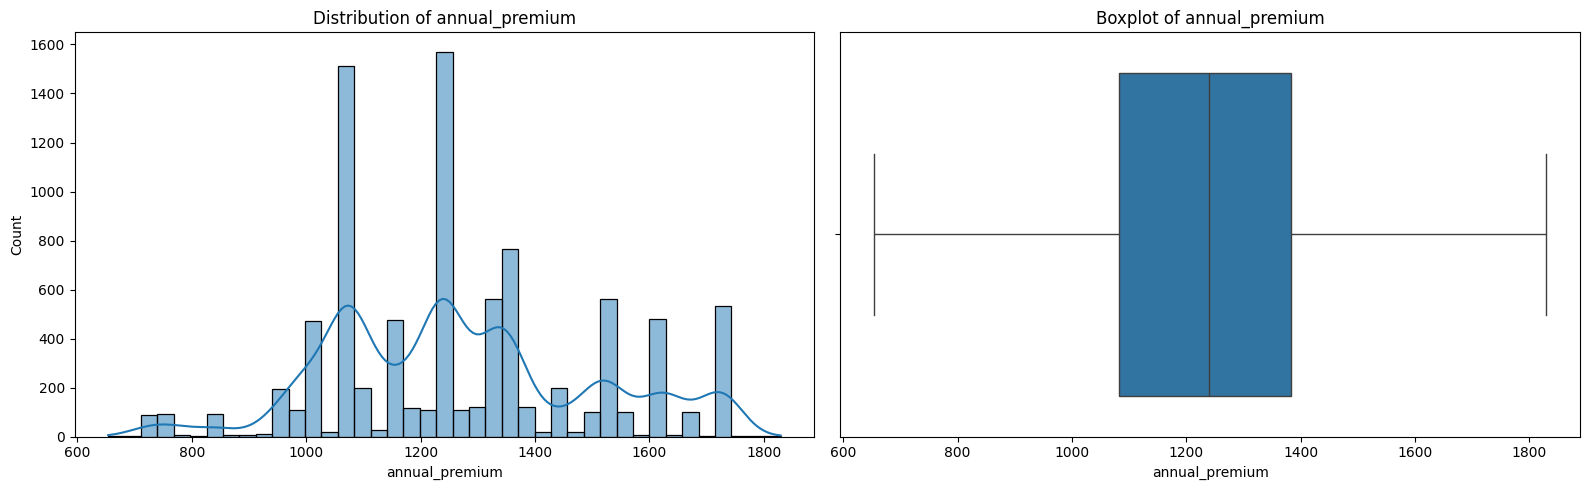

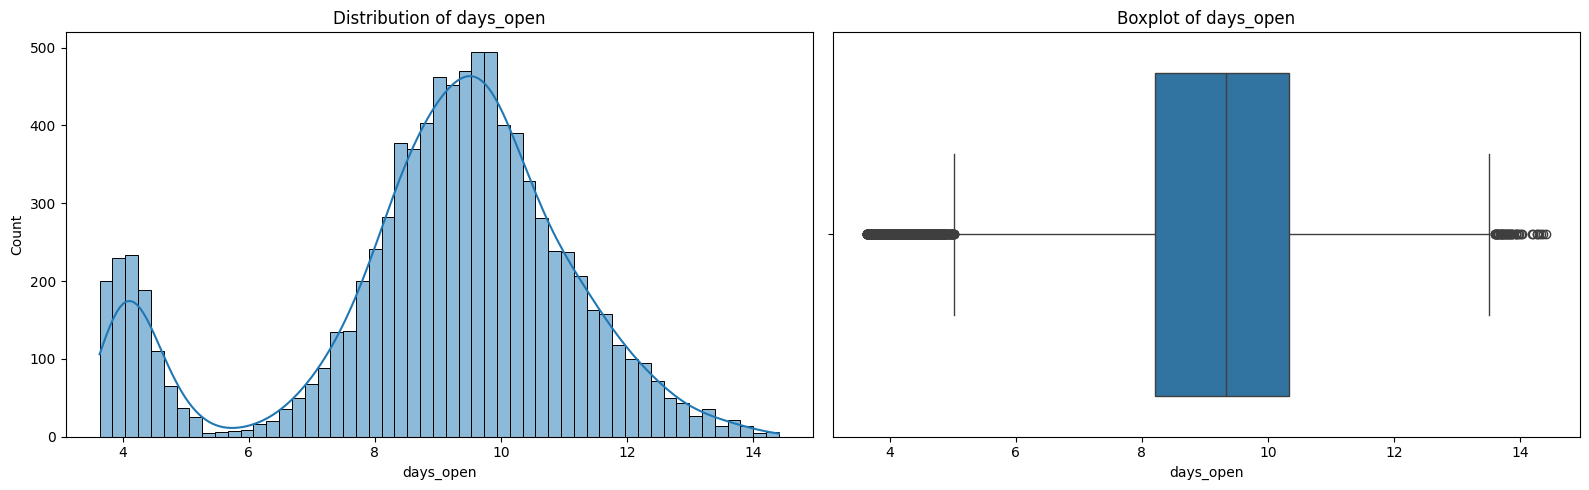

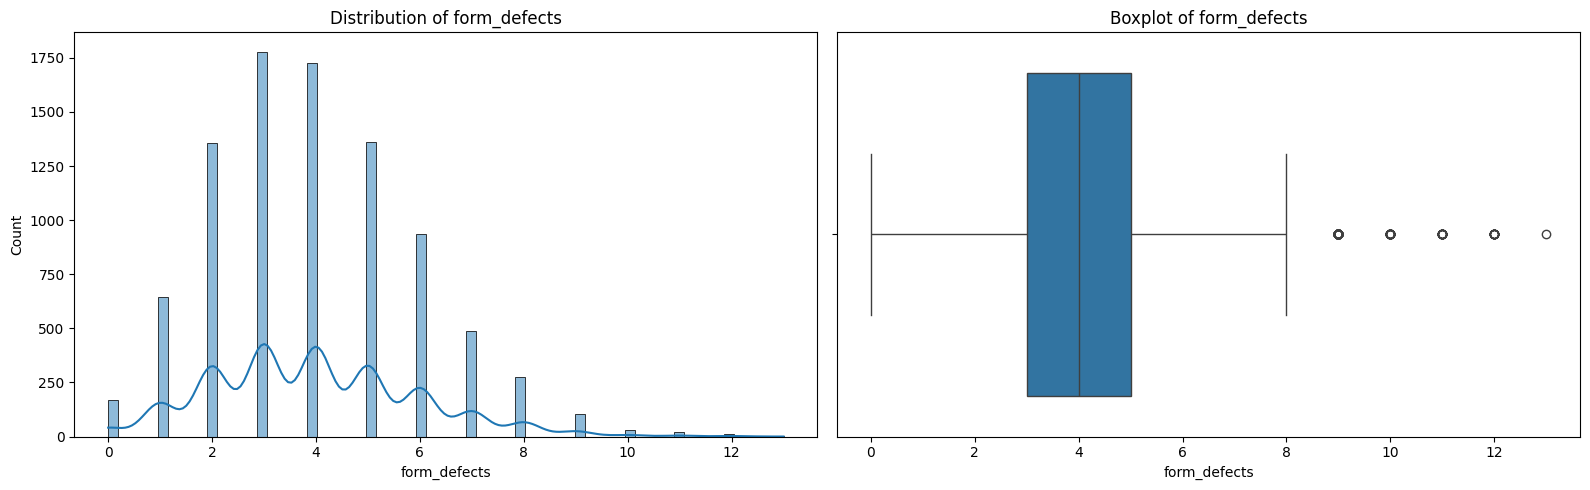

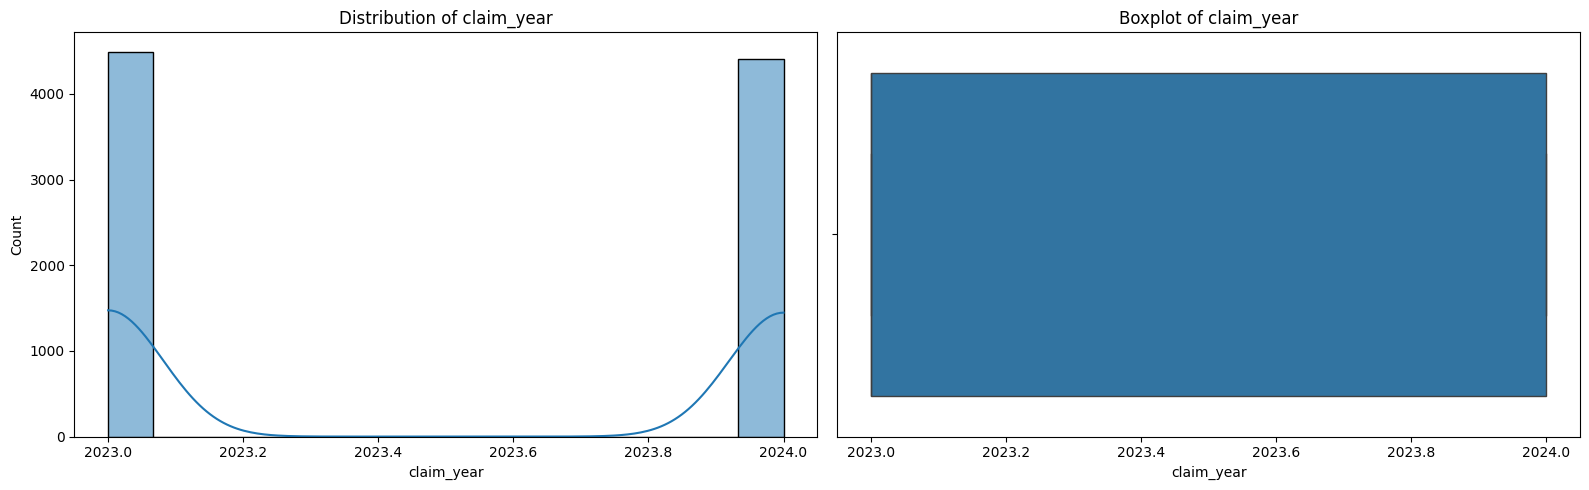

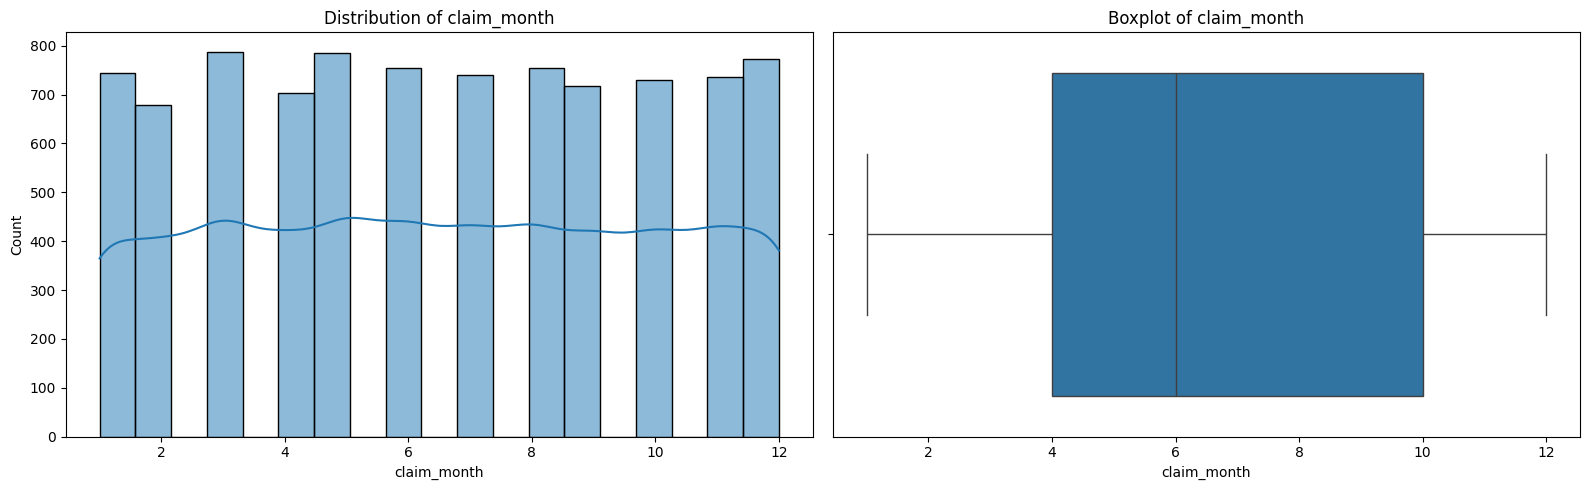

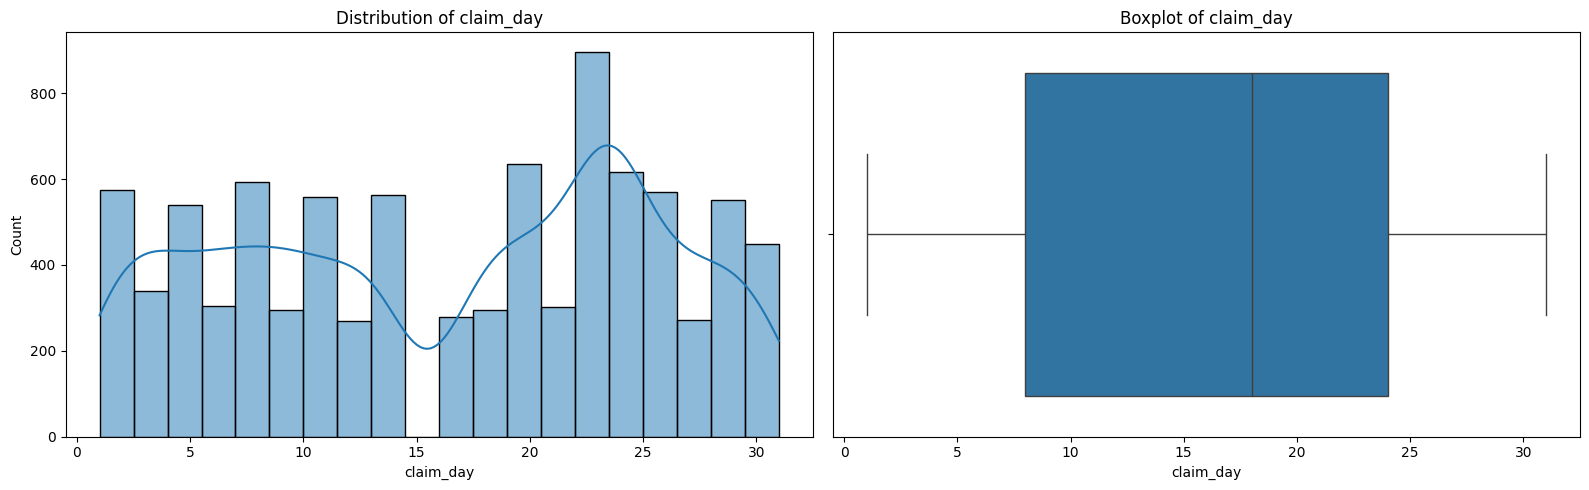

In [8]:
for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

## 6. Feature / Target Split

In [9]:
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

## 7. Categorical Encoding
One-hot encoding for nominal columns, ordinal encoding for `vehicle_category` (has a natural order), label encoding for the target.

In [10]:
ohe_columns = ["gender", "property_status", "claim_day_of_week", "accident_site", "channel", "vehicle_color"]
ordinal_columns = ["vehicle_category"]

transformer = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ohe_columns),
    ("ord", OrdinalEncoder(categories=[["Compact", "Medium", "Large"]]), ordinal_columns)
], remainder="passthrough")

X_encoded = transformer.fit_transform(X)
feature_names = transformer.get_feature_names_out()
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), name="fraud_reported")

## 8. Scaling

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

## 9. Export Preprocessed CSV

In [13]:
final_df = pd.concat([X_scaled, y_encoded], axis=1)
final_df.to_csv("insurance_fraud_data_preprocessed.csv", index=False)
final_df.shape

(8904, 47)